# Energy Consumption Forecasting

This notebook uses the finalized Random Forest model developed in the model training stage to generate 24-hour recursive forecasts of appliance energy consumption.

The forecasting system uses historical appliance consumption together with temporal, lag, and rolling-window features to predict future hourly energy consumption.

The final model uses recursive forecasting, where each predicted value is fed back into the feature generation process to produce the next hourly prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

In [2]:
forecast_df = pd.read_csv(
    "D:/Energy_Forecasting/data/processed/engineered_energy_data.csv",
    parse_dates=["date"]
)

forecast_df = forecast_df.set_index("date")
forecast_df = forecast_df.sort_index()

print("Dataset shape:", forecast_df.shape)
print("First timestamp:", forecast_df.index.min())
print("Last timestamp:", forecast_df.index.max())

Dataset shape: (3121, 37)
First timestamp: 2016-01-18 17:00:00
Last timestamp: 2016-05-27 17:00:00


In [3]:
features = [
    "hour",
    "day_of_week",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_168",
    "rolling_mean_3",
    "rolling_mean_6"
]

target = "Appliances"

print("Features:")
print(features)

print("\nTarget:")
print(target)

print("\nMissing values in forecasting features:")
print(forecast_df[features].isna().sum())

Features:
['hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6']

Target:
Appliances

Missing values in forecasting features:
hour              0
day_of_week       0
is_weekend        0
lag_1             0
lag_2             0
lag_3             0
lag_24            0
lag_48            0
lag_168           0
rolling_mean_3    0
rolling_mean_6    0
dtype: int64


In [4]:
final_model = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

print(final_model)

RandomForestRegressor(max_features='sqrt', n_estimators=300, n_jobs=-1,
                      random_state=42)


In [5]:
X_full = forecast_df[features]
y_full = forecast_df[target]

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

X_full shape: (3121, 11)
y_full shape: (3121,)


In [6]:
final_model.fit(X_full, y_full)

print("Final forecasting model trained successfully.")

Final forecasting model trained successfully.


In [7]:
last_timestamp = forecast_df.index.max()

print("Last historical timestamp:", last_timestamp)

Last historical timestamp: 2016-05-27 17:00:00


In [8]:
first_forecast_timestamp = (
    last_timestamp + pd.Timedelta(hours=1)
)

print(
    "First forecast timestamp:",
    first_forecast_timestamp
)

First forecast timestamp: 2016-05-27 18:00:00


In [9]:
future_timestamps = pd.date_range(
    start=first_forecast_timestamp,
    periods=24,
    freq="h"
)

print("Forecast start:", future_timestamps[0])
print("Forecast end:", future_timestamps[-1])
print("Number of forecast hours:", len(future_timestamps))

Forecast start: 2016-05-27 18:00:00
Forecast end: 2016-05-28 17:00:00
Number of forecast hours: 24


In [10]:
history = forecast_df[[target]].copy()

print("History shape:", history.shape)
print("History last timestamp:", history.index[-1])
print("History last 5 values:")
print(history.tail())

History shape: (3121, 1)
History last timestamp: 2016-05-27 17:00:00
History last 5 values:
                     Appliances
date                           
2016-05-27 13:00:00        1590
2016-05-27 14:00:00         610
2016-05-27 15:00:00         460
2016-05-27 16:00:00         810
2016-05-27 17:00:00        1080


In [11]:
def create_forecast_features(timestamp, history):

    values = history[target]

    features_row = {
        "hour": timestamp.hour,
        "day_of_week": timestamp.dayofweek,
        "is_weekend": int(timestamp.dayofweek >= 5),

        "lag_1": values.iloc[-1],
        "lag_2": values.iloc[-2],
        "lag_3": values.iloc[-3],

        "lag_24": values.iloc[-24],
        "lag_48": values.iloc[-48],
        "lag_168": values.iloc[-168],

        "rolling_mean_3": values.iloc[-3:].mean(),
        "rolling_mean_6": values.iloc[-6:].mean()
    }

    return pd.DataFrame(
        [features_row],
        index=[timestamp]
    )[features]

In [12]:
test_timestamp = future_timestamps[0]

test_features = create_forecast_features(
    test_timestamp,
    history
)

print("Feature shape:", test_features.shape)
print("Feature columns:")
print(test_features.columns.tolist())

print("\nFeature values:")
print(test_features)

Feature shape: (1, 11)
Feature columns:
['hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6']

Feature values:
                     hour  day_of_week  is_weekend  lag_1  lag_2  lag_3  \
2016-05-27 18:00:00    18            4           0   1080    810    460   

                     lag_24  lag_48  lag_168  rolling_mean_3  rolling_mean_6  
2016-05-27 18:00:00    1290     940      470      783.333333      943.333333  


In [13]:
manual_values = history[target]

print("Manual lag_1:", manual_values.iloc[-1])
print("Feature lag_1:", test_features["lag_1"].iloc[0])

print("Manual lag_24:", manual_values.iloc[-24])
print("Feature lag_24:", test_features["lag_24"].iloc[0])

print(
    "Manual rolling_mean_3:",
    manual_values.iloc[-3:].mean()
)

print(
    "Feature rolling_mean_3:",
    test_features["rolling_mean_3"].iloc[0]
)

print(
    "Manual rolling_mean_6:",
    manual_values.iloc[-6:].mean()
)

print(
    "Feature rolling_mean_6:",
    test_features["rolling_mean_6"].iloc[0]
)

Manual lag_1: 1080
Feature lag_1: 1080
Manual lag_24: 1290
Feature lag_24: 1290
Manual rolling_mean_3: 783.3333333333334
Feature rolling_mean_3: 783.3333333333334
Manual rolling_mean_6: 943.3333333333334
Feature rolling_mean_6: 943.3333333333334


In [14]:
first_prediction = final_model.predict(
    test_features
)[0]

print("Forecast timestamp:", test_timestamp)
print("First predicted consumption:", first_prediction)

Forecast timestamp: 2016-05-27 18:00:00
First predicted consumption: 1090.9333333333334


In [15]:
print(
    "Prediction type:",
    type(first_prediction).__name__
)

print(
    "Prediction value:",
    first_prediction
)

Prediction type: float64
Prediction value: 1090.9333333333334


In [16]:
print(
    "Prediction is non-negative:",
    first_prediction >= 0
)

Prediction is non-negative: True


In [ ]:
horizon_rmse = (
    rf_results
    .groupby("forecast_horizon")["Squared_Error"]
    .mean()
    .pow(0.5)
)

horizon_rmse

forecast_horizon
1     474.349773
2     311.230835
3     229.615577
4     170.339088
5     101.350805
6      70.885175
7      42.118763
8      56.974352
9      44.914694
10     52.261713
11     41.504045
12    169.357179
13    126.686381
14    509.337525
15    389.250624
16    511.785020
17    717.101781
18    406.198228
19    507.517798
20    420.789448
21    372.716433
22    406.042834
23    529.958523
24    538.819559
Name: Squared_Error, dtype: float64

In [17]:
# Reset history before starting the actual forecast
history = forecast_df[[target]].copy()

recursive_predictions = []

for timestamp in future_timestamps:

    # Create features using the current history
    forecast_features = create_forecast_features(
        timestamp,
        history
    )

    # Predict the next hour
    prediction = final_model.predict(
        forecast_features
    )[0]

    # Store prediction
    recursive_predictions.append(prediction)

    # Add prediction to history
    history.loc[timestamp, target] = prediction

print("Number of predictions:", len(recursive_predictions))

Number of predictions: 24


In [18]:
forecast_results = pd.DataFrame({
    "date": future_timestamps,
    "Predicted_Appliances": recursive_predictions
})

forecast_results = forecast_results.set_index("date")

print("Forecast shape:", forecast_results.shape)
print("Forecast start:", forecast_results.index[0])
print("Forecast end:", forecast_results.index[-1])

Forecast shape: (24, 1)
Forecast start: 2016-05-27 18:00:00
Forecast end: 2016-05-28 17:00:00


In [19]:
print(forecast_results)

                     Predicted_Appliances
date                                     
2016-05-27 18:00:00           1090.933333
2016-05-27 19:00:00            830.166667
2016-05-27 20:00:00            726.433333
2016-05-27 21:00:00            453.233333
2016-05-27 22:00:00            366.933333
2016-05-27 23:00:00            322.933333
2016-05-28 00:00:00            309.166667
2016-05-28 01:00:00            315.366667
2016-05-28 02:00:00            298.166667
2016-05-28 03:00:00            302.700000
2016-05-28 04:00:00            306.900000
2016-05-28 05:00:00            309.666667
2016-05-28 06:00:00            336.766667
2016-05-28 07:00:00            466.466667
2016-05-28 08:00:00            649.166667
2016-05-28 09:00:00            880.800000
2016-05-28 10:00:00           1030.066667
2016-05-28 11:00:00           1223.266667
2016-05-28 12:00:00           1049.366667
2016-05-28 13:00:00            945.000000
2016-05-28 14:00:00            866.566667
2016-05-28 15:00:00            782

In [20]:
print(
    "Expected predictions:",
    len(future_timestamps)
)

print(
    "Actual predictions:",
    len(forecast_results)
)

print(
    "Duplicate timestamps:",
    forecast_results.index.duplicated().sum()
)

print(
    "Missing predictions:",
    forecast_results["Predicted_Appliances"].isna().sum()
)

Expected predictions: 24
Actual predictions: 24
Duplicate timestamps: 0
Missing predictions: 0


In [21]:
print(
    "Last historical timestamp:",
    last_timestamp
)

print(
    "First forecast timestamp:",
    forecast_results.index[0]
)

print(
    "Time gap:",
    forecast_results.index[0] - last_timestamp
)

Last historical timestamp: 2016-05-27 17:00:00
First forecast timestamp: 2016-05-27 18:00:00
Time gap: 0 days 01:00:00


In [22]:
print(
    "Minimum forecast:",
    forecast_results["Predicted_Appliances"].min()
)

print(
    "Maximum forecast:",
    forecast_results["Predicted_Appliances"].max()
)

print(
    "Mean forecast:",
    forecast_results["Predicted_Appliances"].mean()
)

print(
    "Negative predictions:",
    (
        forecast_results["Predicted_Appliances"] < 0
    ).sum()
)

Minimum forecast: 298.1666666666667
Maximum forecast: 1223.2666666666667
Mean forecast: 659.2430555555555
Negative predictions: 0


In [23]:
display(
    forecast_results.round(2)
)

,Predicted_Appliances
date,
2016-05-27 18:00:00,1090.93
2016-05-27 19:00:00,830.17
2016-05-27 20:00:00,726.43
2016-05-27 21:00:00,453.23
2016-05-27 22:00:00,366.93
2016-05-27 23:00:00,322.93
2016-05-28 00:00:00,309.17
2016-05-28 01:00:00,315.37
2016-05-28 02:00:00,298.17


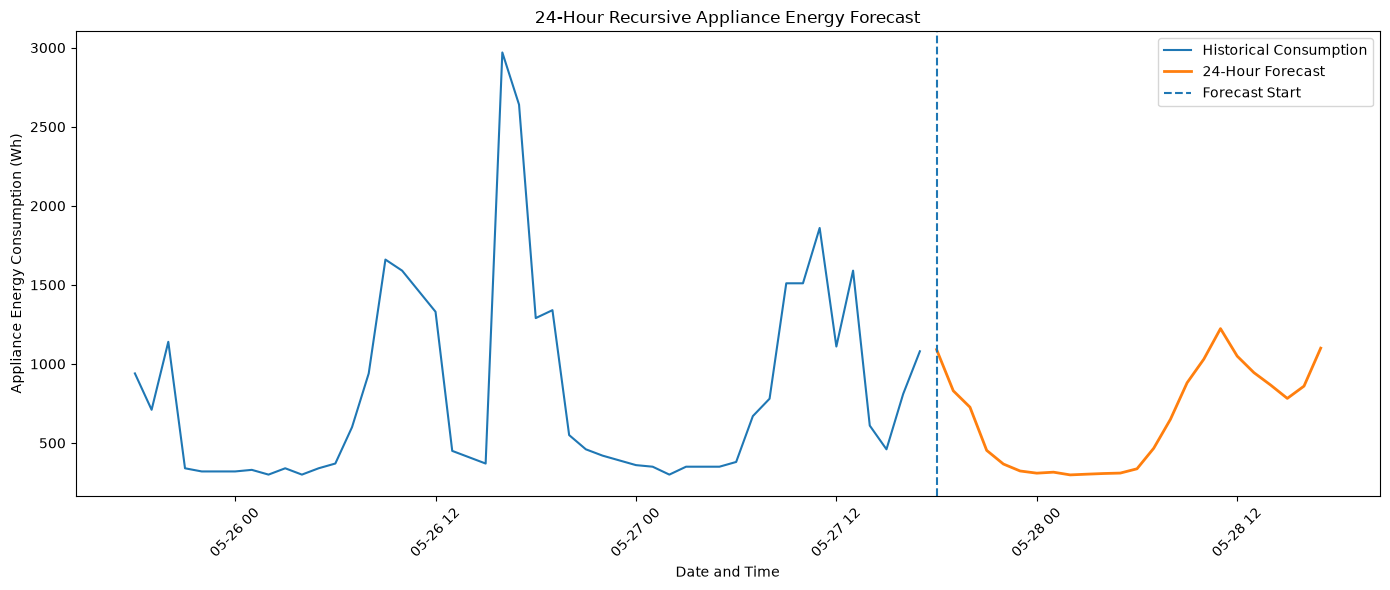

In [24]:
plt.figure(figsize=(14, 6))

historical_plot = forecast_df[target].iloc[-48:]

plt.plot(
    historical_plot.index,
    historical_plot.values,
    label="Historical Consumption"
)

plt.plot(
    forecast_results.index,
    forecast_results["Predicted_Appliances"],
    label="24-Hour Forecast",
    linewidth=2
)

plt.axvline(
    forecast_results.index[0],
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Date and Time")
plt.ylabel("Appliance Energy Consumption (Wh)")
plt.title("24-Hour Recursive Appliance Energy Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [25]:
forecast_results["hour"] = forecast_results.index.hour

print(
    forecast_results[
        ["hour", "Predicted_Appliances"]
    ].round(2)
)

                     hour  Predicted_Appliances
date                                           
2016-05-27 18:00:00    18               1090.93
2016-05-27 19:00:00    19                830.17
2016-05-27 20:00:00    20                726.43
2016-05-27 21:00:00    21                453.23
2016-05-27 22:00:00    22                366.93
2016-05-27 23:00:00    23                322.93
2016-05-28 00:00:00     0                309.17
2016-05-28 01:00:00     1                315.37
2016-05-28 02:00:00     2                298.17
2016-05-28 03:00:00     3                302.70
2016-05-28 04:00:00     4                306.90
2016-05-28 05:00:00     5                309.67
2016-05-28 06:00:00     6                336.77
2016-05-28 07:00:00     7                466.47
2016-05-28 08:00:00     8                649.17
2016-05-28 09:00:00     9                880.80
2016-05-28 10:00:00    10               1030.07
2016-05-28 11:00:00    11               1223.27
2016-05-28 12:00:00    12               

In [26]:
highest_forecast = forecast_results[
    "Predicted_Appliances"
].idxmax()

lowest_forecast = forecast_results[
    "Predicted_Appliances"
].idxmin()

print(
    "Highest predicted consumption:",
    forecast_results.loc[
        highest_forecast,
        "Predicted_Appliances"
    ],
    "Wh at",
    highest_forecast
)

print(
    "Lowest predicted consumption:",
    forecast_results.loc[
        lowest_forecast,
        "Predicted_Appliances"
    ],
    "Wh at",
    lowest_forecast
)

Highest predicted consumption: 1223.2666666666667 Wh at 2016-05-28 11:00:00
Lowest predicted consumption: 298.1666666666667 Wh at 2016-05-28 02:00:00


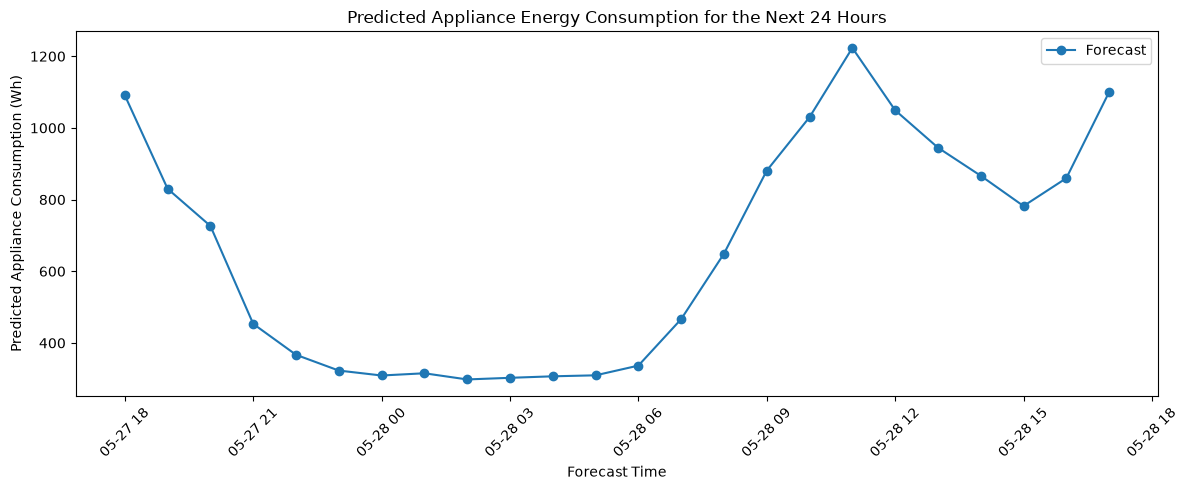

In [27]:
plt.figure(figsize=(12, 5))

plt.plot(
    forecast_results.index,
    forecast_results["Predicted_Appliances"],
    marker="o",
    label="Forecast"
)

plt.xlabel("Forecast Time")
plt.ylabel("Predicted Appliance Consumption (Wh)")
plt.title("Predicted Appliance Energy Consumption for the Next 24 Hours")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

In [28]:
from pathlib import Path

forecast_output_dir = Path(
    "D:/Energy_Forecasting/data/processed"
)

forecast_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [29]:
forecast_output_path = (
    forecast_output_dir /
    "next_24h_energy_forecast.csv"
)

forecast_results.to_csv(
    forecast_output_path
)

print(
    "Forecast saved successfully:",
    forecast_output_path
)

Forecast saved successfully: D:\Energy_Forecasting\data\processed\next_24h_energy_forecast.csv


In [31]:
final_forecast = forecast_results[
    ["Predicted_Appliances"]
].copy()

final_forecast.to_csv(
    forecast_output_path
)

print("Final forecast shape:", final_forecast.shape)
print("Final forecast columns:", final_forecast.columns.tolist())

Final forecast shape: (24, 1)
Final forecast columns: ['Predicted_Appliances']


In [33]:
verified_forecast = pd.read_csv(
    forecast_output_path,
    parse_dates=["date"]
)

print("Verified shape:", verified_forecast.shape)
print("Verified columns:", verified_forecast.columns.tolist())
print("First timestamp:", verified_forecast["date"].iloc[0])
print("Last timestamp:", verified_forecast["date"].iloc[-1])

Verified shape: (24, 2)
Verified columns: ['date', 'Predicted_Appliances']
First timestamp: 2016-05-27 18:00:00
Last timestamp: 2016-05-28 17:00:00


## Forecasting Summary

The finalized Random Forest model was used to generate a 24-hour recursive forecast of appliance energy consumption.

The forecasting process begins with the latest available historical observations. For each future hour, temporal features, lag features, and rolling mean features are generated from the available history. The predicted value is then added to the history and used to construct the features for the following hour.

This recursive procedure is repeated for all 24 future hours.

The resulting forecast is saved as `next_24h_energy_forecast.csv` for potential use by a future forecasting application or dashboard.

In [34]:
import joblib
from pathlib import Path

model_dir = Path("D:/Energy_Forecasting/models")
model_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "final_random_forest.pkl"

joblib.dump(
    final_model,
    model_path
)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
D:\Energy_Forecasting\models\final_random_forest.pkl


In [35]:
loaded_model = joblib.load(model_path)

print("Loaded model:")
print(loaded_model)

print("\nModel parameters:")
print(loaded_model.get_params())

Loaded model:
RandomForestRegressor(max_features='sqrt', n_estimators=300, n_jobs=-1,
                      random_state=42)

Model parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [36]:
import json

features_path = model_dir / "forecast_features.json"

with open(features_path, "w") as f:
    json.dump(features, f, indent=4)

print("Features saved successfully:")
print(features_path)

Features saved successfully:
D:\Energy_Forecasting\models\forecast_features.json


In [37]:
with open(features_path, "r") as f:
    saved_features = json.load(f)

print("Saved features:")
print(saved_features)

print("Number of features:", len(saved_features))

Saved features:
['hour', 'day_of_week', 'is_weekend', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rolling_mean_3', 'rolling_mean_6']
Number of features: 11


In [38]:
print("Files in model directory:")

for file in model_dir.iterdir():
    print(file.name)

Files in model directory:
final_random_forest.pkl
forecast_features.json
